In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart_disease_cleaned.csv")
X = df.drop(["target"], axis=1)
y = df["target"]




In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

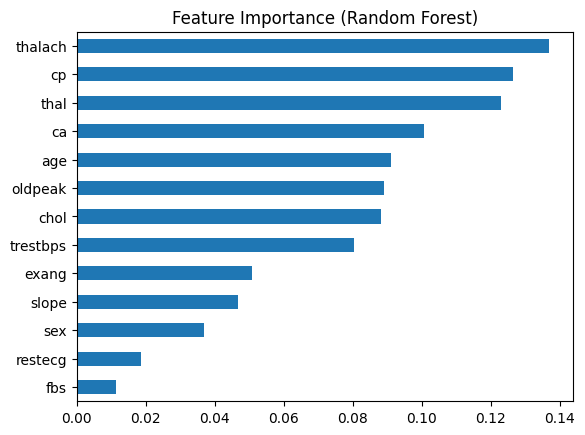

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values()

importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [12]:
print(importances.sort_values(ascending=False))

thalach     0.136890
cp          0.126468
thal        0.122970
ca          0.100674
age         0.090946
oldpeak     0.089189
chol        0.088207
trestbps    0.080259
exang       0.050702
slope       0.046663
sex         0.036954
restecg     0.018679
fbs         0.011398
dtype: float64


In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features_rfe = X.columns[rfe.support_]

print("RFE Selected Features:")
print(selected_features_rfe)

RFE Selected Features:
Index(['sex', 'cp', 'exang', 'slope', 'ca'], dtype='object')


In [14]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi_scores, p_values = chi2(X_scaled, y)

chi_result = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print(chi_result)

     Feature  Chi2 Score       p-value
12      thal   44.877965  2.097045e-11
8      exang   38.052613  6.886243e-10
11        ca   28.038394  1.189323e-07
9    oldpeak   16.817971  4.114184e-05
10     slope   10.984336  9.188519e-04
1        sex    7.432845  6.404399e-03
2         cp    7.384879  6.577449e-03
6    restecg    4.322448  3.761276e-02
7    thalach    2.670638  1.022151e-01
0        age    1.005896  3.158880e-01
3   trestbps    0.619899  4.310847e-01
4       chol    0.251667  6.159039e-01
5        fbs    0.164669  6.848935e-01


In [ ]:
# The 'Golden 8' based on specific Chi2 and RF results:
final_features = ['thal', 'ca', 'cp', 'exang', 'thalach', 'oldpeak', 'age', 'sex']

In [16]:
df_reduced = df[final_features + ["target"]]
df_reduced.to_csv("../data/heart_reduced.csv", index=False)